# Publico: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "publico"
PLAYER = "Publico"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,publico,publico,Publico,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, parse_rfc822_dates",


SpiderProfile(spider='publico', display_name='Publico', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'parse_rfc822_dates'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
22,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,61,61,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Publico,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,61,61,0,2015-09-10 17:55:18+00:00,2026-01-09 12:45:37+00:00,0,19


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,fb16419c638481303f4a4f1bc05b7552409b0b5d095108cdb1246705b3ffb3d7,publico,Publico,publico,https://www.publico.pt/2016/02/16/economia/noticia/as-familias-vao-recuperar-mais-de-700-milhoes-de-euros-de-rendimento-1723529,https://www.publico.pt/2016/02/16/economia/noticia/as-familias-vao-recuperar-mais-de-700-milhoes-de-euros-de-rendimento-1723529,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Tue, 16 Feb 2016 19:56:38 GMT",2026-03-15T03:03:23+00:00,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Num dos v&#xED;deos em que explica o Or&#xE7;amento, Ant&#xF3;nio Costa faz a conta ao valor da reposi&#xE7;&#xE3;o de rendimentos das fam&#xED;lias. Est&#x...",NaN,NaN,pt,PT,[Economia],"[Prova dos Factos, Orçamento do Estado 2016, Função Pública, António Costa, Segurança Social, Orçamento do Estado, Governo, Pensões, Impostos, Rendimento So...",[],NewsArticle,20260315T010005Z-1d265f16,2016-02-16 19:56:38+00:00,2026-03-15 03:03:23+00:00,88303.112500,72,72,166,www.publico.pt,1.0
1,0ed0504945f162ddffeaae336561e243f52d60bebe71f2bec777b98242ba4f21,publico,Publico,publico,https://www.publico.pt/2015/09/10/economia/noticia/a-prova-dos-factos-quantos-pontos-do-irc-quer-o-ps-alocar-a-seguranca-social-1707477,https://www.publico.pt/2015/09/10/economia/noticia/a-prova-dos-factos-quantos-pontos-do-irc-quer-o-ps-alocar-a-seguranca-social-1707477,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Thu, 10 Sep 2015 22:27:17 GMT",2026-03-15T03:05:55+00:00,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Como afirmado por Passos Coelho, s&#xE3;o quatro pontos percentuais do IRC que o PS prev&#xEA; alocar &#xE0; Seguran&#xE7;a Social no seu programa.",NaN,NaN,pt,PT,[Economia],"[Prova dos Factos, Legislativas 2015, Segurança Social, António Costa, PS, Pensões, IRC, Governo, Pedro Passos Coelho, Legislativas 2015 - Prova dos Factos,...",[],NewsArticle,20260315T010005Z-1d265f16,2015-09-10 22:27:17+00:00,2026-03-15 03:05:55+00:00,92116.643889,58,58,147,www.publico.pt,1.0
2,95a177e5f6efd0d6abfb6c6ea9eba6443f365efd7b9e5b67f2494f4c7cddb666,publico,Publico,publico,https://www.publico.pt/2015/09/28/economia/noticia/prova-dos-factos-vamos-pagar-mais-pelo-metro-de-lisboa-subconcessionado-1709254,https://www.publico.pt/2015/09/28/economia/noticia/prova-dos-factos-vamos-pagar-mais-pelo-metro-de-lisboa-subconcessionado-1709254,Vamos pagar mais pelo Metro de Lisboa subconcessionado?,"Mon, 28 Sep 2015 21:32:33 GMT",2026-03-15T03:05:55+00:00,Vamos pagar mais pelo Metro de Lisboa subconcessionado?,Catarina Martins questionou se a concess&#xE3;o do Metro de Lisboa vai afinal custar-nos mais dinheiro do que o regime actual.,NaN,NaN,pt,PT,[Economia],"[Prova dos Factos, Legislativas 2015, Transportes, Serviço público, Catarina Martins, Metro de Lisboa, Empresas públicas, Lisboa, Legislativas 2015 - Prova ...",[],NewsArticle,20260315T010005Z-1d265f16,2015-09-28 21:32:33+00:00,2026-03-15 03:05:55+00:00,91685.556111,55,55,126,www.publico.pt,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_publico:fb16419c638481303f4a4f1bc05b7552409b0b5d095108cdb1246705b3ffb3d7,fb16419c638481303f4a4f1bc05b7552409b0b5d095108cdb1246705b3ffb3d7,factcheck_scrape_publico,https://www.publico.pt/2016/02/16/economia/noticia/as-familias-vao-recuperar-mais-de-700-milhoes-de-euros-de-rendimento-1723529,2016-02-16T19:56:38+00:00,pt,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?",None,None,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Num dos vídeos em que explica o Orçamento, António Costa faz a conta ao valor da reposição de rendimentos das famílias. Está certo?","as famílias vão recuperar 700 milhões de rendimento, como diz o governo? num dos vídeos em que explica o orçamento, antónio costa faz a conta ao valor da re...","as famílias vão recuperar 700 milhões de rendimento, como diz o governo? num dos vídeos em que explica o orçamento, antónio costa faz a conta ao valor da re...",famílias recuperar 700 milhões rendimento governo vídeos explica orçamento antónio costa conta reposição rendimentos famílias certo,o família ir recuperar 700 milhão de rendimento como dizer o governo em um de o vídeo em que explicar o orçamento antónio costa fazer o conta a o valor de o...,NaN,missing,Economia,"[{'text': 'antónio costa', 'label': 'PER', 'start_char': 116, 'end_char': 129}]",claim_summary,204,1,publico,publico,Publico,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,[Economia],"[Prova dos Factos, Orçamento do Estado 2016, Função Pública, António Costa, Segurança Social, Orçamento do Estado, Governo, Pensões, Impostos, Rendimento So...",NaN,2016-02-16 19:56:38+00:00
1,factcheck_scrape_publico:0ed0504945f162ddffeaae336561e243f52d60bebe71f2bec777b98242ba4f21,0ed0504945f162ddffeaae336561e243f52d60bebe71f2bec777b98242ba4f21,factcheck_scrape_publico,https://www.publico.pt/2015/09/10/economia/noticia/a-prova-dos-factos-quantos-pontos-do-irc-quer-o-ps-alocar-a-seguranca-social-1707477,2015-09-10T22:27:17+00:00,pt,Quantos pontos do IRC quer o PS alocar à Segurança Social?,None,None,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Como afirmado por Passos Coelho, são quatro pontos percentuais do IRC que o PS prevê alocar à Segurança Social no seu programa.","quantos pontos do irc quer o ps alocar à segurança social? como afirmado por passos coelho, são quatro pontos percentuais do irc que o ps prevê alocar à seg...","quantos pontos do irc quer o ps alocar à segurança social? como afirmado por passos coelho, são quatro pontos percentuais do irc que o ps prevê alocar à seg...",quantos irc ps alocar segurança social afirmado passos coelho percentuais irc ps prevê alocar segurança social programa,quanto ponto de o irc querer o ps alocar a o segurança social como afirmar por passo coelho ser quatro ponto percentual de o irc que o ps prever alocar a o ...,NaN,missing,Economia,"[{'text': 'irc', 'label': 'MISC', 'start_char': 18, 'end_char': 21}, {'text': 'ps', 'label': 'ORG', 'start_char': 29, 'end_char': 31}, {'text': 'irc', 'labe...",claim_summary,186,4,publico,publico,Publico,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,[Economia],"[Prova dos Factos, Legislativas 2015, Segurança Social, António Costa, PS, Pensões, IRC, Governo, Pedro Passos Coelho, Legislativas 2015 - Prova dos Factos,...",NaN,2015-09-10 22:27:17+00:00
2,factcheck_scrape_publico:95a177e5f6efd0d6abfb6c6ea9eba6443f365efd7b9e5b67f2494f4c7cddb666,95a177e5f6efd0d6

## Text-length histograms by label

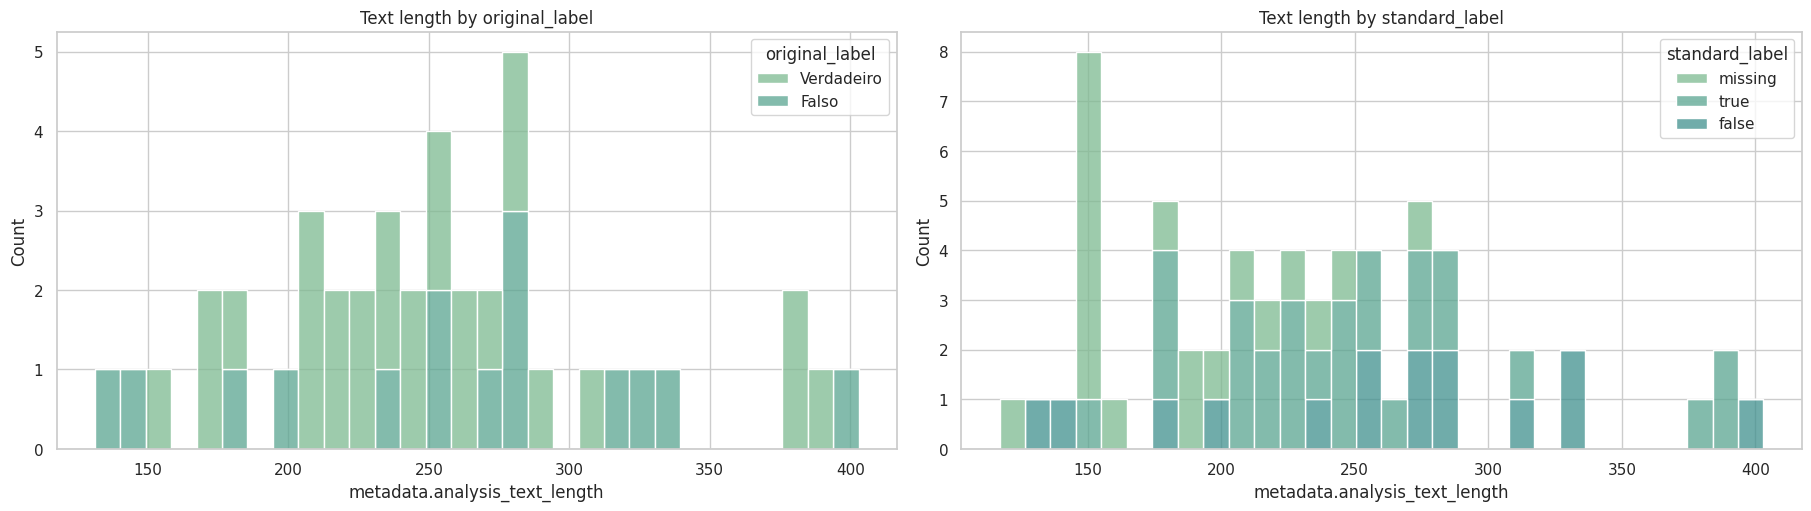

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Economia,61


,topic,count
0,Economia,61


,tag,count
0,Prova dos Factos,61
1,Economia,61
2,Verdadeiro,19
3,Governo,15
4,Legislativas 2015,14
5,Legislativas 2015 - Prova dos Factos,14
6,António Costa,12
7,Falso,12
8,abre conteúdo,9
9,Empresas,8


/tmp/ipykernel_2047944/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
7,2021-05-01,1
8,2021-06-01,1
9,2021-07-01,3
10,2021-10-01,2
11,2021-11-01,2
12,2022-01-01,1
13,2022-03-01,2
14,2022-05-01,1
15,2022-08-01,1
16,2022-09-01,2


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,19
4,rating,19
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,fb16419c638481303f4a4f1bc05b7552409b0b5d095108cdb1246705b3ffb3d7,publico,Publico,publico,https://www.publico.pt/2016/02/16/economia/noticia/as-familias-vao-recuperar-mais-de-700-milhoes-de-euros-de-rendimento-1723529,https://www.publico.pt/2016/02/16/economia/noticia/as-familias-vao-recuperar-mais-de-700-milhoes-de-euros-de-rendimento-1723529,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Tue, 16 Feb 2016 19:56:38 GMT",2026-03-15T03:03:23+00:00,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Num dos v&#xED;deos em que explica o Or&#xE7;amento, Ant&#xF3;nio Costa faz a conta ao valor da reposi&#xE7;&#xE3;o de rendimentos das fam&#xED;lias. Est&#x...",NaN,NaN,pt,PT,[Economia],"[Prova dos Factos, Orçamento do Estado 2016, Função Pública, António Costa, Segurança Social, Orçamento do Estado, Governo, Pensões, Impostos, Rendimento So...",[],NewsArticle,20260315T010005Z-1d265f16,2016-02-16 19:56:38+00:00,2026-03-15 03:03:23+00:00,88303.112500,72,72,166,www.publico.pt,1.0,"As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","As famílias vão recuperar 700 milhões de rendimento, como diz o Governo?","Num dos vídeos em que explica o Orçamento, António Costa faz a conta ao valor da reposição de rendimentos das famílias. Está certo?","as famílias vão recuperar 700 milhões de rendimento, como diz o governo? num dos vídeos em que explica o orçamento, antónio costa faz a conta ao valor da re...",NaN,missing,2016-02-16T19:56:38+00:00
1,0ed0504945f162ddffeaae336561e243f52d60bebe71f2bec777b98242ba4f21,publico,Publico,publico,https://www.publico.pt/2015/09/10/economia/noticia/a-prova-dos-factos-quantos-pontos-do-irc-quer-o-ps-alocar-a-seguranca-social-1707477,https://www.publico.pt/2015/09/10/economia/noticia/a-prova-dos-factos-quantos-pontos-do-irc-quer-o-ps-alocar-a-seguranca-social-1707477,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Thu, 10 Sep 2015 22:27:17 GMT",2026-03-15T03:05:55+00:00,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Como afirmado por Passos Coelho, s&#xE3;o quatro pontos percentuais do IRC que o PS prev&#xEA; alocar &#xE0; Seguran&#xE7;a Social no seu programa.",NaN,NaN,pt,PT,[Economia],"[Prova dos Factos, Legislativas 2015, Segurança Social, António Costa, PS, Pensões, IRC, Governo, Pedro Passos Coelho, Legislativas 2015 - Prova dos Factos,...",[],NewsArticle,20260315T010005Z-1d265f16,2015-09-10 22:27:17+00:00,2026-03-15 03:05:55+00:00,92116.643889,58,58,147,www.publico.pt,1.0,Quantos pontos do IRC quer o PS alocar à Segurança Social?,Quantos pontos do IRC quer o PS alocar à Segurança Social?,"Como afirmado por Passos Coelho, são quatro pontos percentuais do IRC que o PS prevê alocar à Segurança Social no seu programa.","quantos pontos do irc quer o ps alocar à segurança social? como afirmado por passos coelho, são quatro pontos percentuais do irc que o ps prevê alocar à seg...",NaN,missing,2015-09-10T22:27:17+00:00
2,95a177e5f6efd0d6abfb6c6ea9eba6443f365efd7b9e5b67f2494f4c7cddb666,publico,Publico,publico,https://www.publico.pt/2015/09/28/economia/noticia/prova-dos-factos-vamos-pagar-mais-pelo-metro-de-lisboa-subconcessionado-1709254,https://www.publico.pt/2015/09/28/economia/noticia/prova-dos-factos-vamos-pagar-mais-pelo-metro-de-lisboa-subconcessionado-1709254,Vamos pagar mais pelo Metro de Lisboa subconcessionado?,"Mon, 28 Sep 2015 21:32:33 GMT",2026-03-15T03:05:55+00:00,Vamos pagar mais pelo Metro de Lisboa subconcessionado?,Catarina Martins questionou se a concess&#xE3;o do Metro de Lisboa vai afinal custar-nos

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,407
1,de,261
2,em,90
3,ser,66
4,a,56
5,que,53
6,e,39
7,um,33
8,por,30
9,não,29


,text,label,start_char,end_char
0,antónio costa,PER,116,129
1,irc,MISC,18,21
1,ps,ORG,29,31
1,irc,MISC,125,128
1,ps,ORG,135,137
2,metro de lisboa subconcessionado,LOC,22,54
2,catarina martins,PER,56,72
2,metro de lisboa,LOC,102,117
3,passos,LOC,0,6
4,antónio costa,PER,206,219


,label,count
0,LOC,51
1,PER,42
2,ORG,36
3,MISC,13


,source_record_id,text_without_stopwords,lemmatized_text
0,fb16419c638481303f4a4f1bc05b7552409b0b5d095108cdb1246705b3ffb3d7,famílias recuperar 700 milhões rendimento governo vídeos explica orçamento antónio costa conta reposição rendimentos famílias certo,o família ir recuperar 700 milhão de rendimento como dizer o governo em um de o vídeo em que explicar o orçamento antónio costa fazer o conta a o valor de o...
1,0ed0504945f162ddffeaae336561e243f52d60bebe71f2bec777b98242ba4f21,quantos irc ps alocar segurança social afirmado passos coelho percentuais irc ps prevê alocar segurança social programa,quanto ponto de o irc querer o ps alocar a o segurança social como afirmar por passo coelho ser quatro ponto percentual de o irc que o ps prever alocar a o ...
2,95a177e5f6efd0d6abfb6c6ea9eba6443f365efd7b9e5b67f2494f4c7cddb666,vamos pagar metro lisboa subconcessionado catarina martins questionou concessão metro lisboa afinal custar-nos dinheiro regime actual,ir pagar mais por o metro de lisboa subconcessionado catarina martins questionar se o concessão de o metro de lisboa ir afinal custar-nos mais dinheiro de o...
3,f9c6b80fb01a8aa05bc47bd7801326d94f34114509593c2b9730dbbbc2535946,passos único primeiro-ministro entregar país pobre recebeu passos coelho deixar primeiro-ministro eleições tornar-se-á 1976 registar quebra pib durante mandato,passo ser o único primeiro-ministro a entregar o país mais pobre de o que ele receber se passo coelho deixar de ser primeiro-ministro após o eleição tornar-...
4,8201c61a09e2f964e43b30857ad758a8c3a0558d5e28d0462841ace8802b6422,coligação comprometeu-se cortar 600 milhões pensões governo escreveu explicitamente programa estabilidade cortar pensões 600 milhões euros contrário afirmou...,o coligação comprometer se a cortar 600 milhão em o pensão o governo não escrever explicitamente em o programa de estabilidade que ir cortar o pensão em 600...
5,94e55a4454abfc16ecd0fd44a3dee375f25d67ec1d9e2bd2ad8dad17b8de46b8,"vamos pagar défice 2014 efeitos terá facto défice ano passado subido 7,2 causa banco sido vendido","todo ir pagar o défice de 2014 que efeito ter o facto de o défice de o ano passado ter suber para 7,2 por causa de o novo banco ainda não ter ser vender"
6,97fb66c634be49a80d290653c2f5c059a9a040e586f6ee41c97d2510a4320252,ps propõe plafonamento segurança social fraseo contextoo plafonamento segurança social temas destaque debate quarta-feira passos disse proposta ps reduzir d...,o ps propor um plafonamento de o segurança social o fraseo contextoo plafonamento de o segurança social ser um de o tema que estar em destaque em o debate d...
7,4d0d33a5a4a350f59ad7fb56902e859d76cf75e8704fe3d12ef717c6ff0231b5,ps quase duplicou dívida pública paulo portas disse-o acção campanha lisboa desmentem-no,o ps quase duplicar o dívida público paulo porta disse-o em um acção de campanha em lisboa o número desmentem-no
8,85f581f1aa1134fbb316bfacf437ea1b3dbbb71bd14654d6b1987ccfb16712de,grécia cresceu portugal argumento usado antónio costa defender actual ritmo retoma português será,o grécia crescer mais que portugal o argumento ser usar por antónio costa para defender que o actual ritmo de retomar português ser baixo ser mesmo assim
9,1e826307657d03ca2bb6d2e2befe4fba607be6866d6012b7967f8afabb20c3f0,passos criou anos emprego sócrates primeiro-ministro disse jantar-comício coligação terá razão,passo criar em dois ano mais emprego de o que sócrate em seis ser o primeiro-ministro quem ele dizer em o último jantar-comício de o coligação ter razão


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T232125Z-publico,61,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232125Z-publico/spiders/publico.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232125Z-publico/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T232125Z-publico/manifest.json
